In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [4]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam0 : 89
INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam1 : 89
INFO     | setup | Train Dataset       : 178 samples
INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam0 : 6
INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam1 : 6
INFO     | setup | Validation Dataset  : 12 samples


In [5]:
dl = dm.train_dataloader()

In [6]:
batch = next(iter(dl))

In [7]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

rotations = batch.rotations
print(rotations.shape)

torch.Size([188, 3, 32, 32]) torch.Size([188, 3, 32, 32])
torch.Size([188, 2]) torch.Size([188, 2])
torch.Size([188])


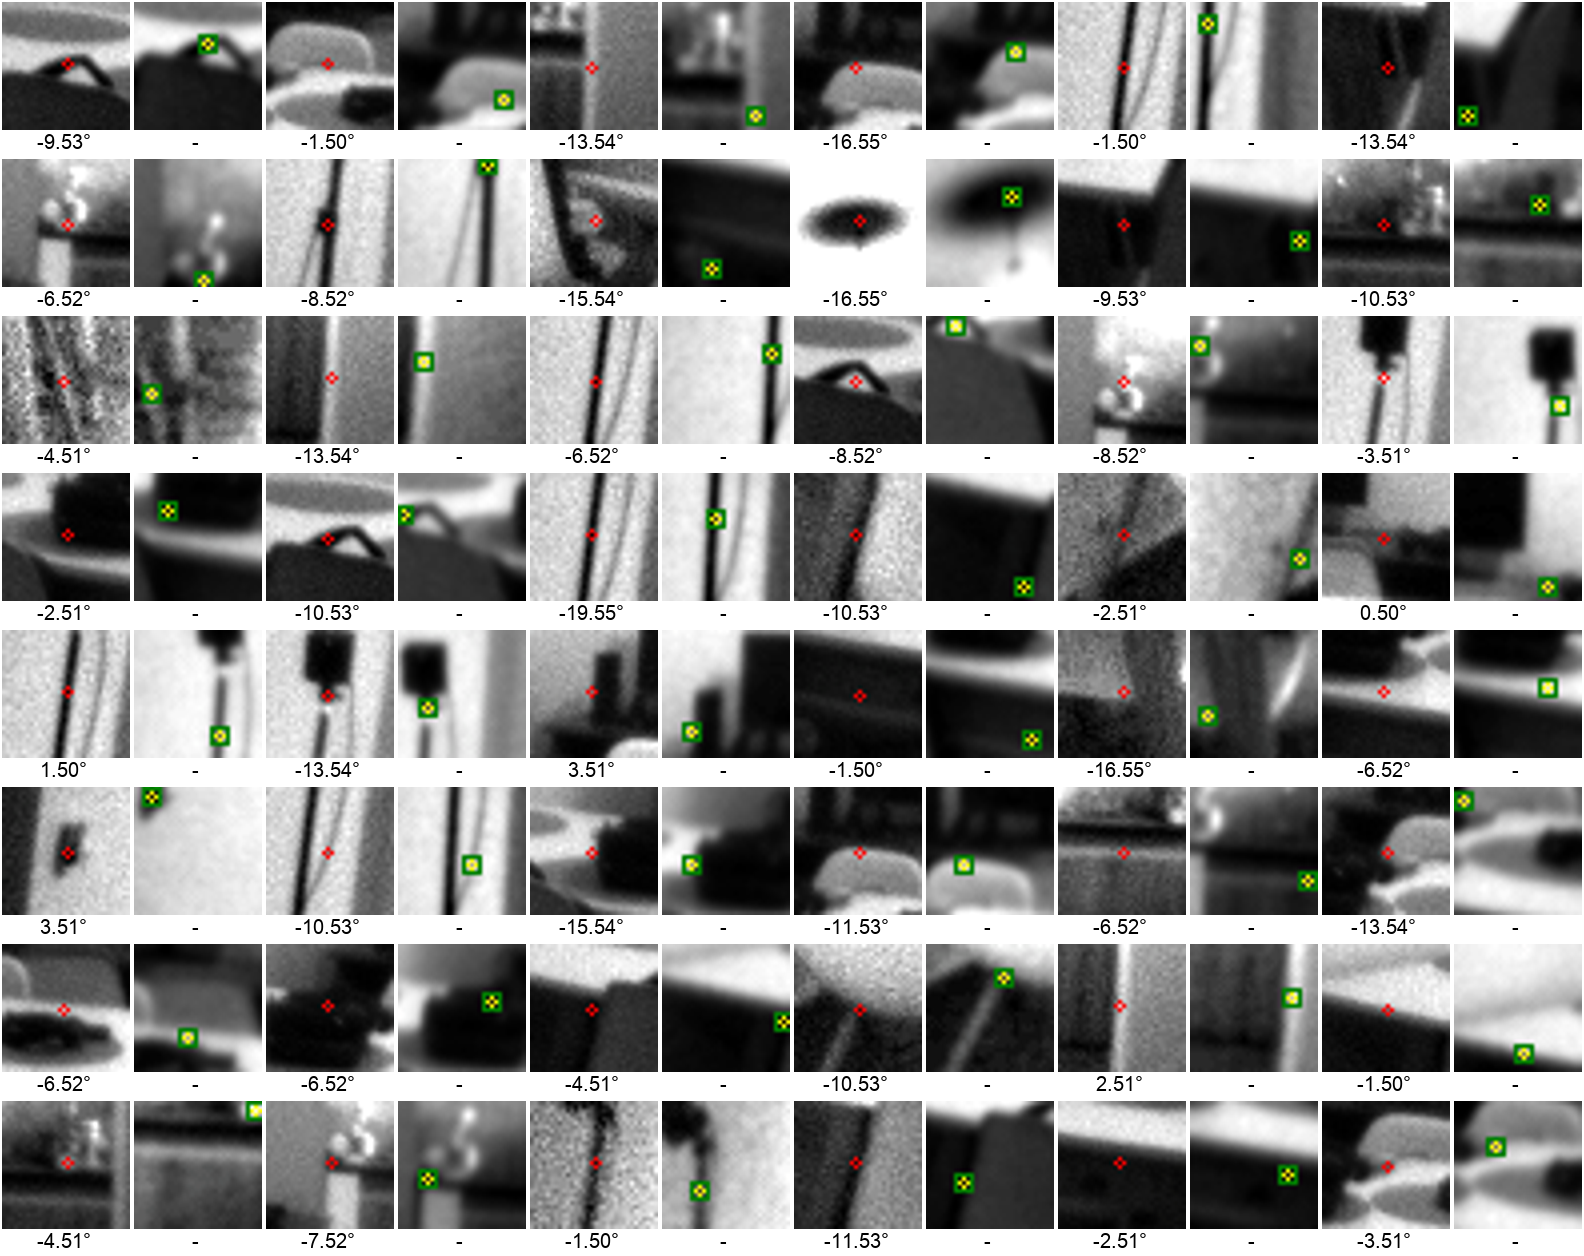

In [8]:
batch = next(iter(dl))

count = 24 * 2

# radians to degrees
# print(batch.rotations[:count] * (180 / torch.pi))

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    rotations_true=batch.rotations,
    rotations=None,
    limit_count=count, 
    n_columns=6,
)

In [9]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)


In [10]:
dm.teardown()

# Check Model

In [11]:
# from src import Light
# light = Light()

In [12]:
# from utils import count_params
# count_params(light.model)

In [13]:
# print(f'reference_patches shape : {reference_patches.shape}')
# print(f'target_patches shape : {target_patches.shape}')
# print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

# reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

# target_coords, target_rotation, target_confidence = light(
#     reference_patches, 
#     target_patches, 
#     patch_level_reference_coords
# )

# print(f'target_coords shape : {target_coords.shape}')
# print(f'target_rotation shape : {target_rotation.shape}')
# print(f'target_confidence shape : {target_confidence.shape}')